# Notebook 7 — Error Analysis

## Research Question 3

> **Which categories are most difficult to classify, and what linguistic characteristics contribute to errors?**

This notebook analyzes the saved test-set predictions from TF-IDF + Logistic Regression, BiLSTM, and DistilBERT.

### Important methodological principle

The models are **not retrained here**. This notebook uses the fixed test set predictions saved after model evaluation.

The analysis includes:

1. Prediction-file validation
2. Overall and per-class performance
3. Confusion matrices
4. Most frequent confusion pairs
5. Misclassified examples
6. Error analysis by text length
7. Manual qualitative error categories
8. Poster-ready summary tables and figures

The test set is the same fixed 8,168-example test set used in the previous experiments.


## 1. Imports and configuration

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from IPython.display import display

RANDOM_STATE = 42

LABELS = [
    "Anxiety",
    "Depression",
    "Happy",
    "Mentalhealth",
    "Normal",
    "Sad",
    "Stress",
    "Suicidal"
]

# Locate the project data folder.
# Notebook 7 is normally inside the Experiment folder, so ../data
# is checked in addition to data.

possible_data_dirs = [
    Path("data"),
    Path("../data")
]

DATA_DIR = None

for path in possible_data_dirs:
    if (path / "results").exists():
        DATA_DIR = path
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find the data folder. "
        "Please make sure Notebook 7 is inside the project folder "
        "or the Experiment folder."
    )

RESULTS_DIR = DATA_DIR / "results"

# Figures are stored in the project-level figures folder.
FIGURES_DIR = DATA_DIR.parent / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project directories loaded.")


Project directories loaded.


## 2. Load the three prediction files

In [2]:
prediction_files = {
    "TF-IDF + Logistic Regression": RESULTS_DIR / "tfidf_test_predictions.csv",
    "BiLSTM": RESULTS_DIR / "bilstm_test_predictions.csv",
    "DistilBERT": RESULTS_DIR / "distilbert_test_predictions.csv"
}

print("Checking prediction files...")

for model_name, path in prediction_files.items():
    print(f"{model_name}: loaded successfully.")
    if not path.exists():
        raise FileNotFoundError(
            f"Could not find the prediction file for {model_name}: {path}\n"
            "Check that the CSV files are inside the project's data/results folder."
        )

predictions = {}

for model_name, path in prediction_files.items():
    df = pd.read_csv(path)

    required_columns = {"text", "true_label", "predicted_label"}
    missing = required_columns - set(df.columns)

    if missing:
        raise ValueError(
            f"{model_name} prediction file is missing columns: {sorted(missing)}"
        )

    predictions[model_name] = df

    print(f"{model_name}: {len(df):,} rows")

print("\nAll prediction files loaded successfully.")


Checking prediction files...
TF-IDF + Logistic Regression: loaded successfully.
BiLSTM: loaded successfully.
DistilBERT: loaded successfully.
TF-IDF + Logistic Regression: 8,168 rows
BiLSTM: 8,168 rows
DistilBERT: 8,168 rows

All prediction files loaded successfully.


## 3. Validate the prediction files

Before analyzing errors, we check that all models use the same fixed test set and the expected eight labels.


In [3]:
for model_name, df in predictions.items():
    print(f"\n{model_name}")
    print("-" * len(model_name))
    print("Rows:", len(df))
    print("Missing text:", df["text"].isna().sum())
    print("Missing true labels:", df["true_label"].isna().sum())
    print("Missing predictions:", df["predicted_label"].isna().sum())

    unexpected_true = sorted(set(df["true_label"].dropna()) - set(LABELS))
    unexpected_pred = sorted(set(df["predicted_label"].dropna()) - set(LABELS))

    print("Unexpected true labels:", unexpected_true)
    print("Unexpected predicted labels:", unexpected_pred)

    assert len(df) == 8168, (
        f"{model_name} has {len(df)} rows; expected 8,168."
    )
    assert df["text"].notna().all()
    assert df["true_label"].notna().all()
    assert df["predicted_label"].notna().all()
    assert not unexpected_true
    assert not unexpected_pred

print("\nBasic validation passed.")



TF-IDF + Logistic Regression
----------------------------
Rows: 8168
Missing text: 0
Missing true labels: 0
Missing predictions: 0
Unexpected true labels: []
Unexpected predicted labels: []

BiLSTM
------
Rows: 8168
Missing text: 0
Missing true labels: 0
Missing predictions: 0
Unexpected true labels: []
Unexpected predicted labels: []

DistilBERT
----------
Rows: 8168
Missing text: 0
Missing true labels: 0
Missing predictions: 0
Unexpected true labels: []
Unexpected predicted labels: []

Basic validation passed.


In [4]:
# Verify that the same test texts and true labels are used for all three models.

reference = predictions["TF-IDF + Logistic Regression"][["text", "true_label"]].reset_index(drop=True)

for model_name, df in predictions.items():
    current = df[["text", "true_label"]].reset_index(drop=True)
    assert current.equals(reference), (
        f"{model_name} does not have exactly the same test texts/labels "
        "as the TF-IDF prediction file."
    )

print("Fixed-test-set consistency check passed.")


Fixed-test-set consistency check passed.


## 4. Overall test performance

These metrics are recomputed from the saved predictions as a consistency check against the results from Notebooks 3–5.


In [5]:
overall_results = []

for model_name, df in predictions.items():
    y_true = df["true_label"]
    y_pred = df["predicted_label"]

    overall_results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(
            y_true, y_pred, labels=LABELS, average="macro", zero_division=0
        ),
        "macro_recall": recall_score(
            y_true, y_pred, labels=LABELS, average="macro", zero_division=0
        ),
        "macro_f1": f1_score(
            y_true, y_pred, labels=LABELS, average="macro", zero_division=0
        ),
        "weighted_f1": f1_score(
            y_true, y_pred, labels=LABELS, average="weighted", zero_division=0
        )
    })

overall_results_df = pd.DataFrame(overall_results)

display(
    overall_results_df.style.format({
        "accuracy": "{:.4f}",
        "macro_precision": "{:.4f}",
        "macro_recall": "{:.4f}",
        "macro_f1": "{:.4f}",
        "weighted_f1": "{:.4f}"
    })
)


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,TF-IDF + Logistic Regression,0.7512,0.6832,0.7387,0.7022,0.7524
1,BiLSTM,0.7178,0.6262,0.6705,0.6425,0.7227
2,DistilBERT,0.7883,0.7340,0.7682,0.7449,0.7908


## 5. Per-class performance

Per-class F1 is especially useful here because the dataset is imbalanced and some categories are much smaller than others.


In [6]:
per_class_rows = []

for model_name, df in predictions.items():
    report = classification_report(
        df["true_label"],
        df["predicted_label"],
        labels=LABELS,
        output_dict=True,
        zero_division=0
    )

    for label in LABELS:
        per_class_rows.append({
            "model": model_name,
            "label": label,
            "precision": report[label]["precision"],
            "recall": report[label]["recall"],
            "f1": report[label]["f1-score"],
            "support": int(report[label]["support"])
        })

per_class_df = pd.DataFrame(per_class_rows)

per_class_f1 = per_class_df.pivot(
    index="label",
    columns="model",
    values="f1"
).reindex(LABELS)

display(per_class_f1.round(4))


model,BiLSTM,DistilBERT,TF-IDF + Logistic Regression
label,,,
Anxiety,0.7647,0.8645,0.7959
Depression,0.6773,0.7224,0.6947
Happy,0.6100,0.7937,0.7411
Mentalhealth,0.5674,0.6646,0.6354
Normal,0.9007,0.9483,0.9008
Sad,0.4831,0.5596,0.5584
Stress,0.5068,0.6983,0.6068
Suicidal,0.6302,0.7081,0.6845


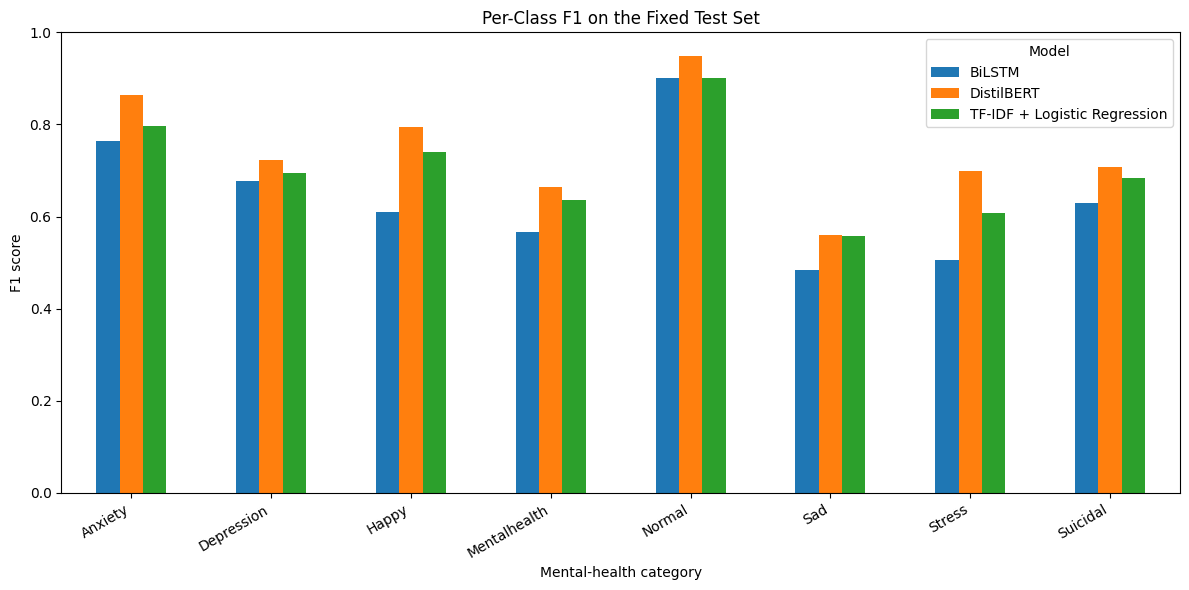

Saved: ..\figures\per_class_f1_comparison.png


In [7]:
# per-class F1 figure

ax = per_class_f1.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title("Per-Class F1 on the Fixed Test Set")
ax.set_xlabel("Mental-health category")
ax.set_ylabel("F1 score")
ax.set_ylim(0, 1)
ax.legend(title="Model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

per_class_fig = FIGURES_DIR / "per_class_f1_comparison.png"
plt.savefig(per_class_fig, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", per_class_fig)


## 6. Confusion matrices

Rows represent the **true class** and columns represent the **predicted class**.


In [8]:
confusion_matrices = {}

for model_name, df in predictions.items():
    cm = confusion_matrix(
        df["true_label"],
        df["predicted_label"],
        labels=LABELS
    )
    confusion_matrices[model_name] = cm

    print(f"\n{model_name}")
    display(pd.DataFrame(cm, index=LABELS, columns=LABELS))



TF-IDF + Logistic Regression


,Anxiety,Depression,Happy,Mentalhealth,Normal,Sad,Stress,Suicidal
Anxiety,540,25,2,31,37,5,43,4
Depression,72,1480,2,39,111,57,84,530
Happy,1,0,73,4,11,13,0,0
Mentalhealth,9,1,2,203,5,68,0,4
Normal,15,22,7,1,2211,3,129,17
Sad,1,1,7,51,7,172,0,7
Stress,27,30,0,0,12,0,267,7
Suicidal,5,327,2,18,110,52,14,1190



BiLSTM


,Anxiety,Depression,Happy,Mentalhealth,Normal,Sad,Stress,Suicidal
Anxiety,525,32,1,25,27,7,64,6
Depression,39,1514,0,40,55,43,98,586
Happy,0,0,61,5,5,30,1,0
Mentalhealth,19,7,5,179,1,70,0,11
Normal,38,52,14,0,2123,11,130,37
Sad,4,4,11,70,3,143,0,11
Stress,49,36,0,0,24,0,223,11
Suicidal,12,451,6,20,71,42,21,1095



DistilBERT


,Anxiety,Depression,Happy,Mentalhealth,Normal,Sad,Stress,Suicidal
Anxiety,587,23,2,22,11,2,37,3
Depression,24,1559,0,31,32,41,55,633
Happy,1,1,75,5,0,19,1,0
Mentalhealth,13,8,0,214,1,45,0,11
Normal,14,20,3,1,2247,1,98,21
Sad,0,6,5,69,2,155,0,9
Stress,28,12,0,0,12,0,287,4
Suicidal,4,312,2,10,29,45,1,1315


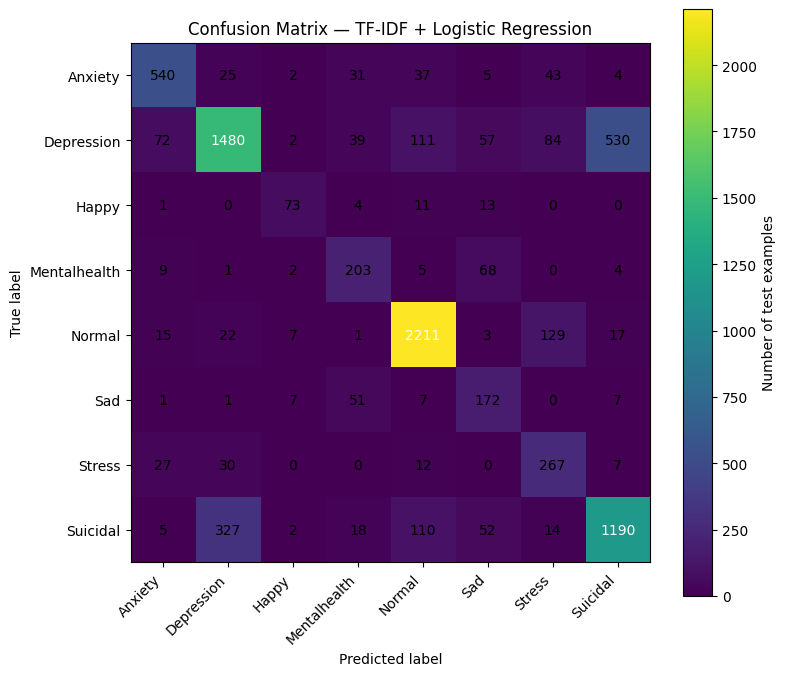

Saved: tf-idf_logistic_regression_confusion_matrix.png


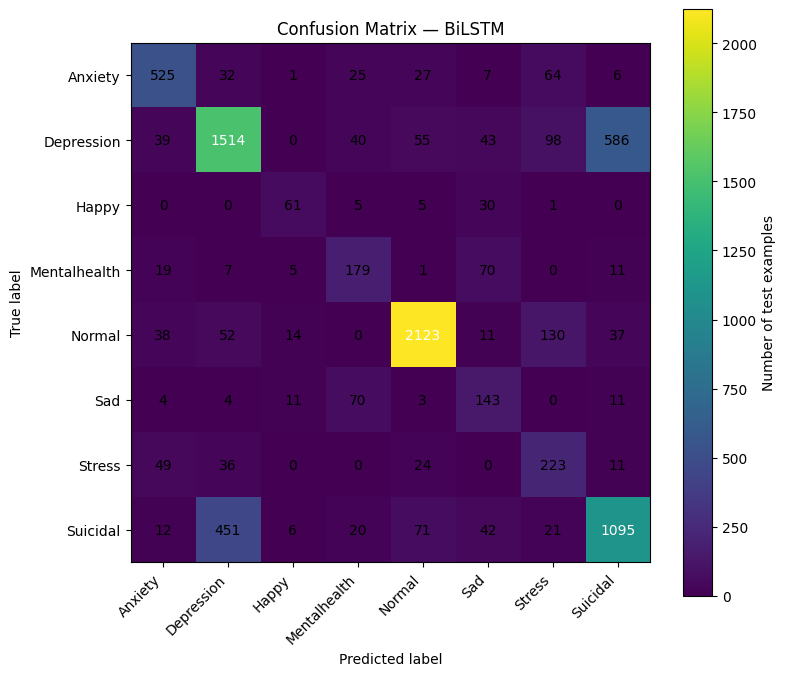

Saved: bilstm_confusion_matrix.png


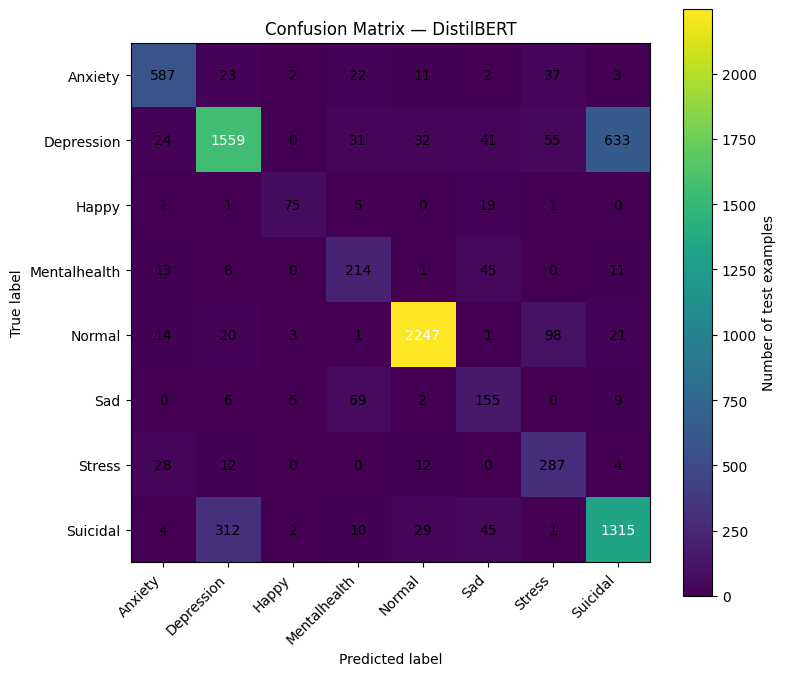

Saved: distilbert_confusion_matrix.png


In [9]:
# Generate one confusion-matrix figure for each model.

for model_name, cm in confusion_matrices.items():
    fig, ax = plt.subplots(figsize=(8, 7))

    image = ax.imshow(cm)

    ax.set_xticks(range(len(LABELS)))
    ax.set_yticks(range(len(LABELS)))
    ax.set_xticklabels(LABELS, rotation=45, ha="right")
    ax.set_yticklabels(LABELS)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(f"Confusion Matrix — {model_name}")

    threshold = cm.max() / 2

    for i in range(len(LABELS)):
        for j in range(len(LABELS)):
            ax.text(
                j, i, cm[i, j],
                ha="center",
                va="center",
                color="white" if cm[i, j] > threshold else "black"
            )

    fig.colorbar(image, ax=ax, label="Number of test examples")
    plt.tight_layout()

    safe_name = (
        model_name.lower()
        .replace(" + ", "_")
        .replace(" ", "_")
    )

    figure_path = FIGURES_DIR / f"{safe_name}_confusion_matrix.png"
    plt.savefig(figure_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", figure_path.name)


## 7. Most frequent confusion pairs

Correct predictions on the diagonal are excluded. This identifies which true/predicted class pairs account for the largest numbers of errors.


In [10]:
def get_confusion_pairs(df, top_n=10):
    errors = df[df["true_label"] != df["predicted_label"]].copy()

    pairs = (
        errors.groupby(["true_label", "predicted_label"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    return pairs

confusion_pair_tables = {}

for model_name, df in predictions.items():
    pairs = get_confusion_pairs(df, top_n=10)
    confusion_pair_tables[model_name] = pairs

    print(f"\n{model_name} — Top confusion pairs")
    display(pairs)



TF-IDF + Logistic Regression — Top confusion pairs


,true_label,predicted_label,count
0,Depression,Suicidal,530
1,Suicidal,Depression,327
2,Normal,Stress,129
3,Depression,Normal,111
4,Suicidal,Normal,110
5,Depression,Stress,84
6,Depression,Anxiety,72
7,Mentalhealth,Sad,68
8,Depression,Sad,57
9,Suicidal,Sad,52



BiLSTM — Top confusion pairs


,true_label,predicted_label,count
0,Depression,Suicidal,586
1,Suicidal,Depression,451
2,Normal,Stress,130
3,Depression,Stress,98
4,Suicidal,Normal,71
5,Mentalhealth,Sad,70
6,Sad,Mentalhealth,70
7,Anxiety,Stress,64
8,Depression,Normal,55
9,Normal,Depression,52



DistilBERT — Top confusion pairs


,true_label,predicted_label,count
0,Depression,Suicidal,633
1,Suicidal,Depression,312
2,Normal,Stress,98
3,Sad,Mentalhealth,69
4,Depression,Stress,55
5,Suicidal,Sad,45
6,Mentalhealth,Sad,45
7,Depression,Sad,41
8,Anxiety,Stress,37
9,Depression,Normal,32


In [11]:
# Combined poster-ready confusion-pair table

top_pairs_rows = []

for model_name, pairs in confusion_pair_tables.items():
    for _, row in pairs.iterrows():
        top_pairs_rows.append({
            "model": model_name,
            "true_label": row["true_label"],
            "predicted_label": row["predicted_label"],
            "errors": int(row["count"])
        })

top_confusion_pairs_df = pd.DataFrame(top_pairs_rows)

display(top_confusion_pairs_df)


,model,true_label,predicted_label,errors
0,TF-IDF + Logistic Regression,Depression,Suicidal,530
1,TF-IDF + Logistic Regression,Suicidal,Depression,327
2,TF-IDF + Logistic Regression,Normal,Stress,129
3,TF-IDF + Logistic Regression,Depression,Normal,111
4,TF-IDF + Logistic Regression,Suicidal,Normal,110
5,TF-IDF + Logistic Regression,Depression,Stress,84
6,TF-IDF + Logistic Regression,Depression,Anxiety,72
7,TF-IDF + Logistic Regression,Mentalhealth,Sad,68
8,TF-IDF + Logistic Regression,Depression,Sad,57
9,TF-IDF + Logistic Regression,Suicidal,Sad,52


## 8. Misclassified examples

The following tables show actual test examples rather than synthetic or manually invented examples.


In [12]:
for model_name, df in predictions.items():
    errors = df[df["true_label"] != df["predicted_label"]].copy()

    print(f"\n{model_name}")
    print(f"Total misclassified examples: {len(errors):,}")

    display(
        errors[
            ["text", "true_label", "predicted_label"]
        ].head(10)
    )



TF-IDF + Logistic Regression
Total misclassified examples: 2,032


,text,true_label,predicted_label
2,it is a lot more easier for people to cry at s...,Suicidal,Depression
19,I wanted to end myself so many times I cannot ...,Depression,Suicidal
32,the way my parents handle my emotions is if I ...,Depression,Suicidal
38,Over the last 18 months we have become closer ...,Normal,Depression
47,Is misery better than nothing? Assuming that n...,Suicidal,Normal
50,Do you experience sudden mood shifts? Are ther...,Depression,Normal
51,"I will get better someday, but I will not be l...",Depression,Suicidal
58,I want to die been thinking about it a lot its...,Depression,Suicidal
59,i am gon na make sure i m dead by tomorrow mor...,Depression,Suicidal
64,"selfishness ""I don't feel very good, it's lik...",Anxiety,Depression



BiLSTM
Total misclassified examples: 2,305


,text,true_label,predicted_label
2,it is a lot more easier for people to cry at s...,Suicidal,Depression
8,darkened jade yep work started badly and ha go...,Normal,Depression
19,I wanted to end myself so many times I cannot ...,Depression,Suicidal
31,"even though usually the porridge is delicious,...",Normal,Stress
32,the way my parents handle my emotions is if I ...,Depression,Suicidal
33,huge slight nsfw disturbing stuff everyday hel...,Sad,Mentalhealth
34,My life is worthless.I have done everything I ...,Suicidal,Depression
35,Happiness is not measured by how much you have...,Normal,Depression
44,advice recently quit job realized might done s...,Sad,Anxiety
47,Is misery better than nothing? Assuming that n...,Suicidal,Depression



DistilBERT
Total misclassified examples: 1,729


,text,true_label,predicted_label
2,it is a lot more easier for people to cry at s...,Suicidal,Depression
4,but things are really beginning to fall apart....,Depression,Suicidal
19,I wanted to end myself so many times I cannot ...,Depression,Suicidal
27,my mom accused me of stealing her drugs again ...,Depression,Suicidal
32,the way my parents handle my emotions is if I ...,Depression,Suicidal
33,huge slight nsfw disturbing stuff everyday hel...,Sad,Mentalhealth
39,I felt safe and I actually felt something when...,Depression,Suicidal
44,advice recently quit job realized might done s...,Sad,Mentalhealth
50,Do you experience sudden mood shifts? Are ther...,Depression,Stress
51,"I will get better someday, but I will not be l...",Depression,Suicidal


## 9. Error analysis by text length

Text length is measured in whitespace-separated tokens. The bins are aligned with the sequence-length setting used in the neural-model experiments and provide a simple way to inspect whether short or long texts are harder to classify.


In [13]:
def add_length_bins(df):
    result = df.copy()
    result["token_count"] = result["text"].astype(str).str.split().str.len()

    result["length_bin"] = pd.cut(
        result["token_count"],
        bins=[-1, 32, 64, 128, np.inf],
        labels=["≤32", "33–64", "65–128", ">128"]
    )

    return result

length_results = {}

for model_name, df in predictions.items():
    length_df = add_length_bins(df)

    grouped_rows = []

    for length_bin, group in length_df.groupby("length_bin", observed=False):
        grouped_rows.append({
            "length_bin": length_bin,
            "n_examples": len(group),
            "errors": (group["true_label"] != group["predicted_label"]).sum(),
            "error_rate": (
                group["true_label"] != group["predicted_label"]
            ).mean(),
            "macro_f1": f1_score(
                group["true_label"],
                group["predicted_label"],
                labels=LABELS,
                average="macro",
                zero_division=0
            )
        })

    grouped = pd.DataFrame(grouped_rows)

    grouped["model"] = model_name
    length_results[model_name] = grouped

    print(f"\n{model_name}")
    display(grouped.round(4))



TF-IDF + Logistic Regression


,length_bin,n_examples,errors,error_rate,macro_f1,model
0,≤32,3175,495,0.1559,0.6343,TF-IDF + Logistic Regression
1,33–64,1175,373,0.3174,0.7055,TF-IDF + Logistic Regression
2,65–128,1662,577,0.3472,0.6323,TF-IDF + Logistic Regression
3,>128,2156,587,0.2723,0.5908,TF-IDF + Logistic Regression



BiLSTM


,length_bin,n_examples,errors,error_rate,macro_f1,model
0,≤32,3175,537,0.1691,0.5804,BiLSTM
1,33–64,1175,414,0.3523,0.6273,BiLSTM
2,65–128,1662,624,0.3755,0.5902,BiLSTM
3,>128,2156,730,0.3386,0.5127,BiLSTM



DistilBERT


,length_bin,n_examples,errors,error_rate,macro_f1,model
0,≤32,3175,353,0.1112,0.7127,DistilBERT
1,33–64,1175,302,0.2570,0.7596,DistilBERT
2,65–128,1662,462,0.2780,0.7121,DistilBERT
3,>128,2156,612,0.2839,0.6001,DistilBERT


model,BiLSTM,DistilBERT,TF-IDF + Logistic Regression
length_bin,,,
33–64,0.3523,0.2570,0.3174
65–128,0.3755,0.2780,0.3472
>128,0.3386,0.2839,0.2723
≤32,0.1691,0.1112,0.1559


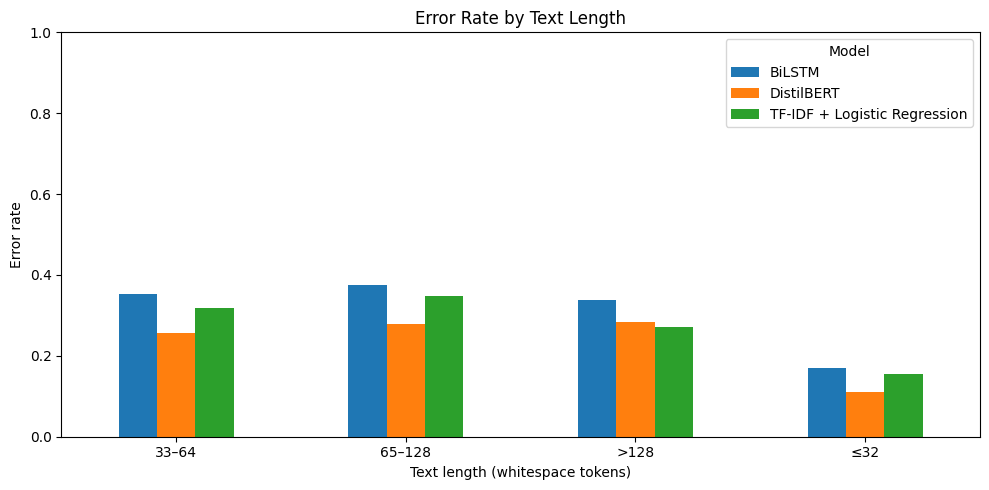

Saved: ..\figures\error_rate_by_text_length.png


In [14]:
length_error_df = pd.concat(
    length_results.values(),
    ignore_index=True
)

length_error_pivot = length_error_df.pivot(
    index="length_bin",
    columns="model",
    values="error_rate"
)

display(length_error_pivot.round(4))

ax = length_error_pivot.plot(
    kind="bar",
    figsize=(10, 5)
)

ax.set_title("Error Rate by Text Length")
ax.set_xlabel("Text length (whitespace tokens)")
ax.set_ylabel("Error rate")
ax.set_ylim(0, 1)
ax.legend(title="Model")
plt.xticks(rotation=0)
plt.tight_layout()

length_fig = FIGURES_DIR / "error_rate_by_text_length.png"
plt.savefig(length_fig, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", length_fig)


## 10. Qualitative error sample for manual analysis

This section creates a reproducible sample of errors for manual inspection.

**Do not automatically assign linguistic explanations in code.** The categories should be based on reading the actual examples.


In [15]:
# Select up to 30 errors per model.
# A fixed random state makes the sample reproducible.

manual_error_samples = {}

for model_name, df in predictions.items():
    errors = df[df["true_label"] != df["predicted_label"]].copy()

    sample_size = min(30, len(errors))

    sample = errors.sample(
        n=sample_size,
        random_state=RANDOM_STATE
    ).reset_index(drop=True)

    sample.insert(0, "error_id", range(1, len(sample) + 1))
    sample["token_count"] = sample["text"].astype(str).str.split().str.len()

    manual_error_samples[model_name] = sample

    print(f"\n{model_name} — manual error sample")
    display(
        sample[
            [
                "error_id",
                "text",
                "true_label",
                "predicted_label",
                "token_count"
            ]
        ]
    )



TF-IDF + Logistic Regression — manual error sample


,error_id,text,true_label,predicted_label,token_count
0,1,Once upon a time there were a happy male. Need...,Suicidal,Depression,421
1,2,I just need to vent and receive some advice/ e...,Normal,Stress,112
2,3,Is anybody else tired all the time? Even if I ...,Anxiety,Depression,36
3,4,So I have had suicidal ideation come and go fo...,Depression,Suicidal,81
4,5,know wrong episode past couple day almost sure...,Mentalhealth,Sad,34
5,6,relapsed fuck,Suicidal,Normal,2
6,7,"I'm afraid about what they may do next, what t...",Stress,Depression,84
7,8,get anxious lie punished way talking lie catch...,Anxiety,Mentalhealth,57
8,9,Please forgive the inarticulate wording of thi...,Depression,Suicidal,426
9,10,finally decided plan excited finally come soli...,Suicidal,Happy,58



BiLSTM — manual error sample


,error_id,text,true_label,predicted_label,token_count
0,1,I always used to think it was me...that someth...,Depression,Suicidal,133
1,2,Son has weird bump on shoulder I'm waiting for...,Anxiety,Stress,146
2,3,It always feels so peaceful the first 5 second...,Depression,Suicidal,233
3,4,I am in therapy. I am medicated. I have lost 3...,Depression,Suicidal,90
4,5,"Crazy, it's been almost a year since CB left a...",Normal,Anxiety,11
5,6,i feel like a horrible person. I am on the bri...,Suicidal,Depression,187
6,7,"When I look in the mirror I want to vomit, whe...",Depression,Suicidal,211
7,8,Does anyone feel the same? I was wondering if ...,Stress,Anxiety,266
8,9,Everything hurts. My therapist told me to go o...,Suicidal,Depression,50
9,10,feel like going crazy know anymore know reacti...,Sad,Mentalhealth,44



DistilBERT — manual error sample


,error_id,text,true_label,predicted_label,token_count
0,1,gay bff best wingman ever got boy number milit...,Happy,Sad,224
1,2,please help cheated boyfriend bestfriend took ...,Sad,Mentalhealth,34
2,3,I can' t do this anymore... I want to finish i...,Depression,Suicidal,35
3,4,"But I do not know where that is, anymore. And ...",Depression,Suicidal,26
4,5,what is there to do other than rot theres noth...,Depression,Suicidal,12
5,6,suffering Anxiety problem falling asleep soffr...,Anxiety,Mentalhealth,124
6,7,Tired of kickin you bitches out the house ð...,Suicidal,Normal,23
7,8,feel tired sudden feel rlly numb exhausted tim...,Mentalhealth,Depression,35
8,9,Comence terapia e [opcionyo.com]( cambio la vi...,Depression,Normal,11
9,10,cut live life give want give want call quits s...,Mentalhealth,Suicidal,37


## 11. Manual error-category template

After reading the sampled examples, use the following categories where applicable:

- **Semantic overlap** — the text contains cues associated with both the true and predicted categories.
- **Ambiguous wording** — the wording does not clearly indicate one category.
- **Short / low-context text** — too little textual evidence is available.
- **Multiple mental-health signals** — several conditions or emotional states appear together.
- **Informal / social-media language** — slang, abbreviations, unusual spelling, or fragmented language.
- **Insufficient context** — the text depends on information that is not explicitly stated.

The table below is intentionally created for **manual annotation**. Do not claim a category unless the example has been inspected.


In [16]:
# Create a manual annotation template for the 30 sampled errors per model.

annotation_rows = []

for model_name, sample in manual_error_samples.items():
    for _, row in sample.iterrows():
        annotation_rows.append({
            "model": model_name,
            "error_id": row["error_id"],
            "text": row["text"],
            "true_label": row["true_label"],
            "predicted_label": row["predicted_label"],
            "token_count": row["token_count"],
            "error_category": "",
            "notes": ""
        })

manual_annotation_df = pd.DataFrame(annotation_rows)

display(manual_annotation_df.head(10))


,model,error_id,text,true_label,predicted_label,token_count,error_category,notes
0,TF-IDF + Logistic Regression,1,Once upon a time there were a happy male. Need...,Suicidal,Depression,421,,
1,TF-IDF + Logistic Regression,2,I just need to vent and receive some advice/ e...,Normal,Stress,112,,
2,TF-IDF + Logistic Regression,3,Is anybody else tired all the time? Even if I ...,Anxiety,Depression,36,,
3,TF-IDF + Logistic Regression,4,So I have had suicidal ideation come and go fo...,Depression,Suicidal,81,,
4,TF-IDF + Logistic Regression,5,know wrong episode past couple day almost sure...,Mentalhealth,Sad,34,,
5,TF-IDF + Logistic Regression,6,relapsed fuck,Suicidal,Normal,2,,
6,TF-IDF + Logistic Regression,7,"I'm afraid about what they may do next, what t...",Stress,Depression,84,,
7,TF-IDF + Logistic Regression,8,get anxious lie punished way talking lie catch...,Anxiety,Mentalhealth,57,,
8,TF-IDF + Logistic Regression,9,Please forgive the inarticulate wording of thi...,Depression,Suicidal,426,,
9,TF-IDF + Logistic Regression,10,finally decided plan excited finally come soli...,Suicidal,Happy,58,,


## 12. Save error-analysis tables

The prediction CSVs are not modified. These are additional analysis outputs.


In [17]:
# Save analysis tables

overall_results_df.to_csv(
    RESULTS_DIR / "error_analysis_overall_metrics.csv",
    index=False
)

per_class_df.to_csv(
    RESULTS_DIR / "error_analysis_per_class_metrics.csv",
    index=False
)

top_confusion_pairs_df.to_csv(
    RESULTS_DIR / "error_analysis_confusion_pairs.csv",
    index=False
)

length_error_df.to_csv(
    RESULTS_DIR / "error_analysis_text_length.csv",
    index=False
)

manual_annotation_df.to_csv(
    RESULTS_DIR / "error_analysis_manual_annotation_template.csv",
    index=False
)

print("Error-analysis tables saved.")


Error-analysis tables saved.


## 13. Poster-ready interpretation guide

Use the observed results to answer RQ3.

Focus on:

1. Which categories have the lowest F1 scores.
2. Which confusion pairs occur most frequently.
3. Whether the same categories are difficult across models or whether difficulty is model-specific.
4. Whether error rates change with text length.
5. What patterns are visible in the manually inspected examples.

### Important reporting rule

Do not claim that a particular linguistic phenomenon causes an error based only on the confusion matrix. Use the actual misclassified examples to support qualitative explanations.

A suitable final statement will have the form:

> **Error analysis showed that the most difficult categories were [observed categories]. The most frequent confusions were [observed pairs]. Manual inspection suggested [observed patterns], particularly in examples with [observed characteristics].**

Replace the bracketed parts only after inspecting the actual outputs.


## 14. Final checklist

Before using the results on the poster:

- [ ] All three prediction files contain 8,168 test examples.
- [ ] Test texts and true labels are identical across all three models.
- [ ] Overall metrics agree with Notebooks 3–5.
- [ ] Confusion matrices are based on the fixed test set.
- [ ] Confusion-pair counts are derived from actual predictions.
- [ ] Manual error explanations are based on inspected examples.
- [ ] Text-length analysis is reported descriptively.
- [ ] No test examples were used for model tuning.
